# Config

In [10]:
import pandas as pd
import openpyxl
import re
import ftfy
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR
from plots import plot_satisfaction_bar, plot_satisfaction_bar_plotnine, plot_target_correlations, analyze_ppe_usage, usage_summary
pd.set_option('future.no_silent_downcasting', True)

# Read data

In [11]:
file_path = RAW_DATA_DIR / "FCTAES_279691_TOTAL_20251006.xlsx"

datos_df = pd.read_excel(file_path, sheet_name="Datos")
print("Datos",datos_df.shape)

# labels_df = pd.read_excel(file_path, sheet_name="Labels")
# print("Labels",labels_df.shape)

variables_df = pd.read_excel(file_path, sheet_name="Variables")
print("Variables",variables_df.shape)

# codes_df = pd.read_excel(file_path, sheet_name="Codes")
# print("Codes",codes_df.shape)

Datos (1813, 514)
Variables (515, 4)


# Data processing

## Filter rows

In [12]:
motocycle_df = datos_df.copy()

# Get only the columns related to motorcycle and moped usage
motocycle_df = motocycle_df[motocycle_df.iloc[:, 22] == 1]

print("After filtering motorcycle/moped users:", motocycle_df.shape)

After filtering motorcycle/moped users: (905, 514)


## Define useful column groups

In [13]:
demographics_col = ['SEXO', 'EDAD',  'CITY_ES',
       'CITY_IT', 'CITY_GB', 'CITY_DK', 'CITY_GR']
# print(datos_df.columns[:25])
# datos_df[demographics_col]


# Analysis Personal Protection Equipment

### Helmet
Available data for helmet usage by motocyclists:
- **Ownership** (Column 8)
- **Satisfaction** (Column 10)

Helmet users: 859 , Helmet ownership rate: 0.95 %


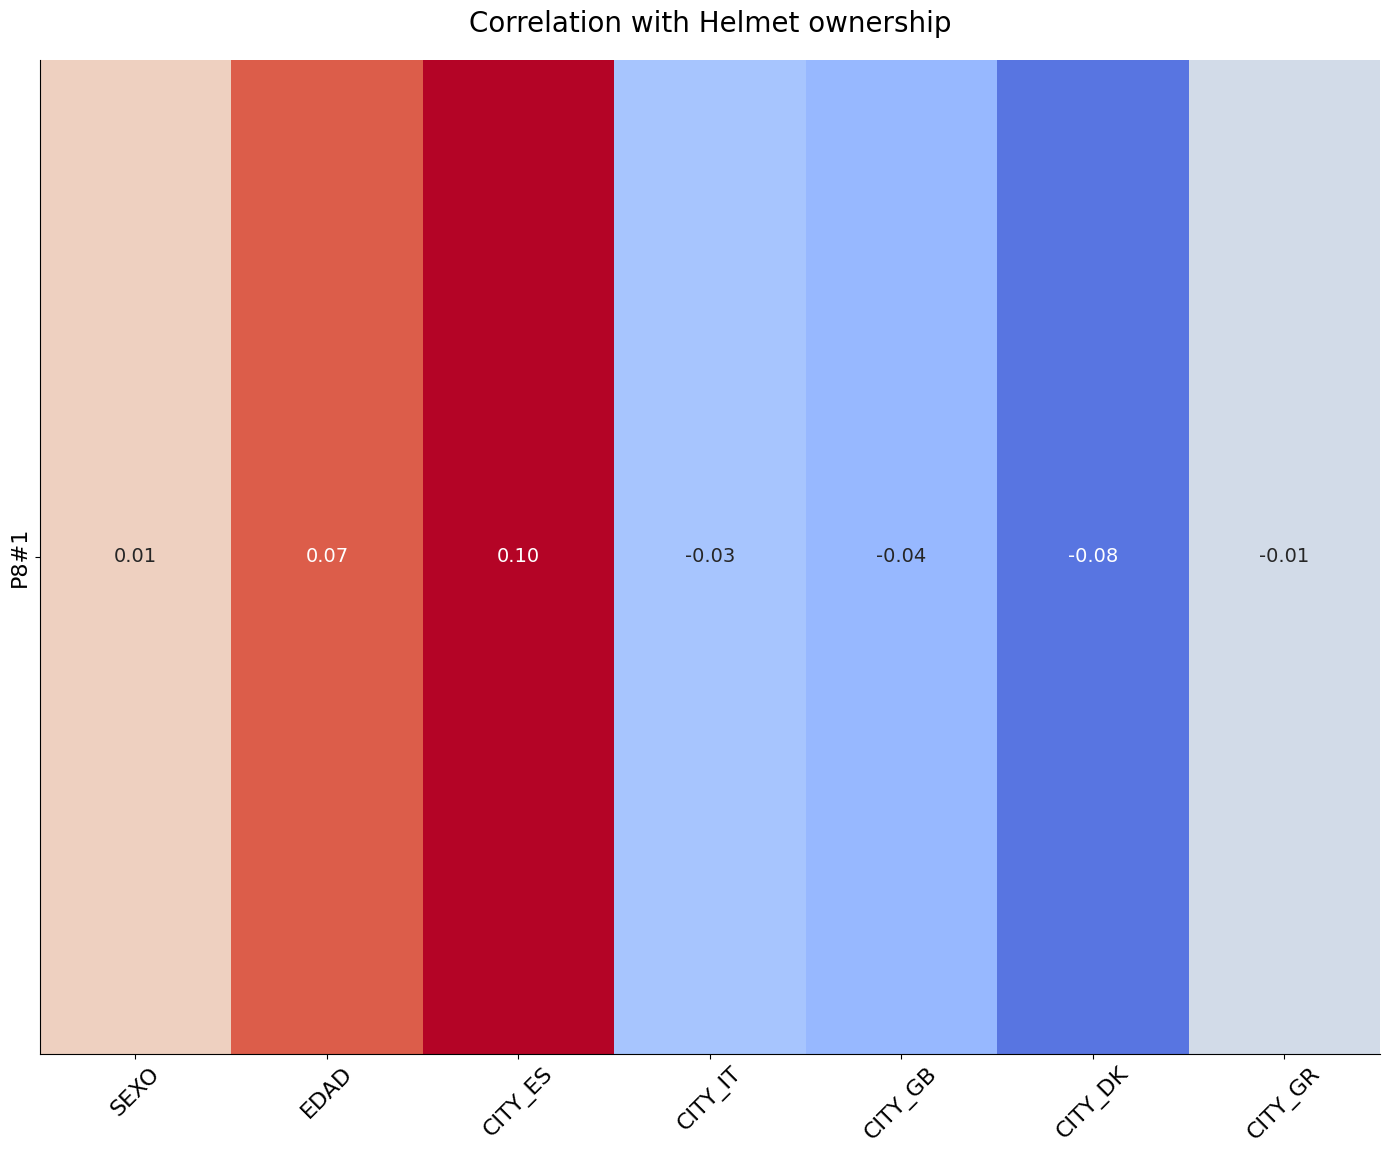

In [14]:
# Helmet ownership
helmet_df = motocycle_df[motocycle_df.iloc[:, 44] == 1]
print("Helmet users:", helmet_df.shape[0], ", Helmet ownership rate:", round(helmet_df.shape[0] / motocycle_df.shape[0], 2),"%")

motocycle_df.iloc[:, 44].value_counts()


# Example usage
target_col = helmet_df.columns[44]
helmet_corr =  plot_target_correlations(
    df=motocycle_df,
    target_col=target_col,
    numeric_cols=[target_col] + demographics_col,
    label = "Helmet ownership",

)

In [15]:
cols = helmet_df.columns[62:66]
helmet_satisfaction = plot_satisfaction_bar_plotnine(
    df=helmet_df,
    cols=cols,
    variables_df=variables_df,
    title = "Satisfaction with helmet")
helmet_satisfaction.save(FIGURES_DIR/"helmet_satisfaction.png")

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 14 x 11.64 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\helmet_satisfaction.png


### Jacket with protection

Available data for leg protector usage by motocyclists:

- **Ownership** (Column 8)
- **Satisfaction** (Column 11)
- **Frequency of usage** (Column 13)
- **Reasons for not using** (Column 14)
- **Statements** (Column 15)
- **Type** (Column 16)


PPE owners: 546, Ownership rate: 60.33%
Ownership value counts:
P8#2
1.0    546
0.0    359
Name: count, dtype: int64


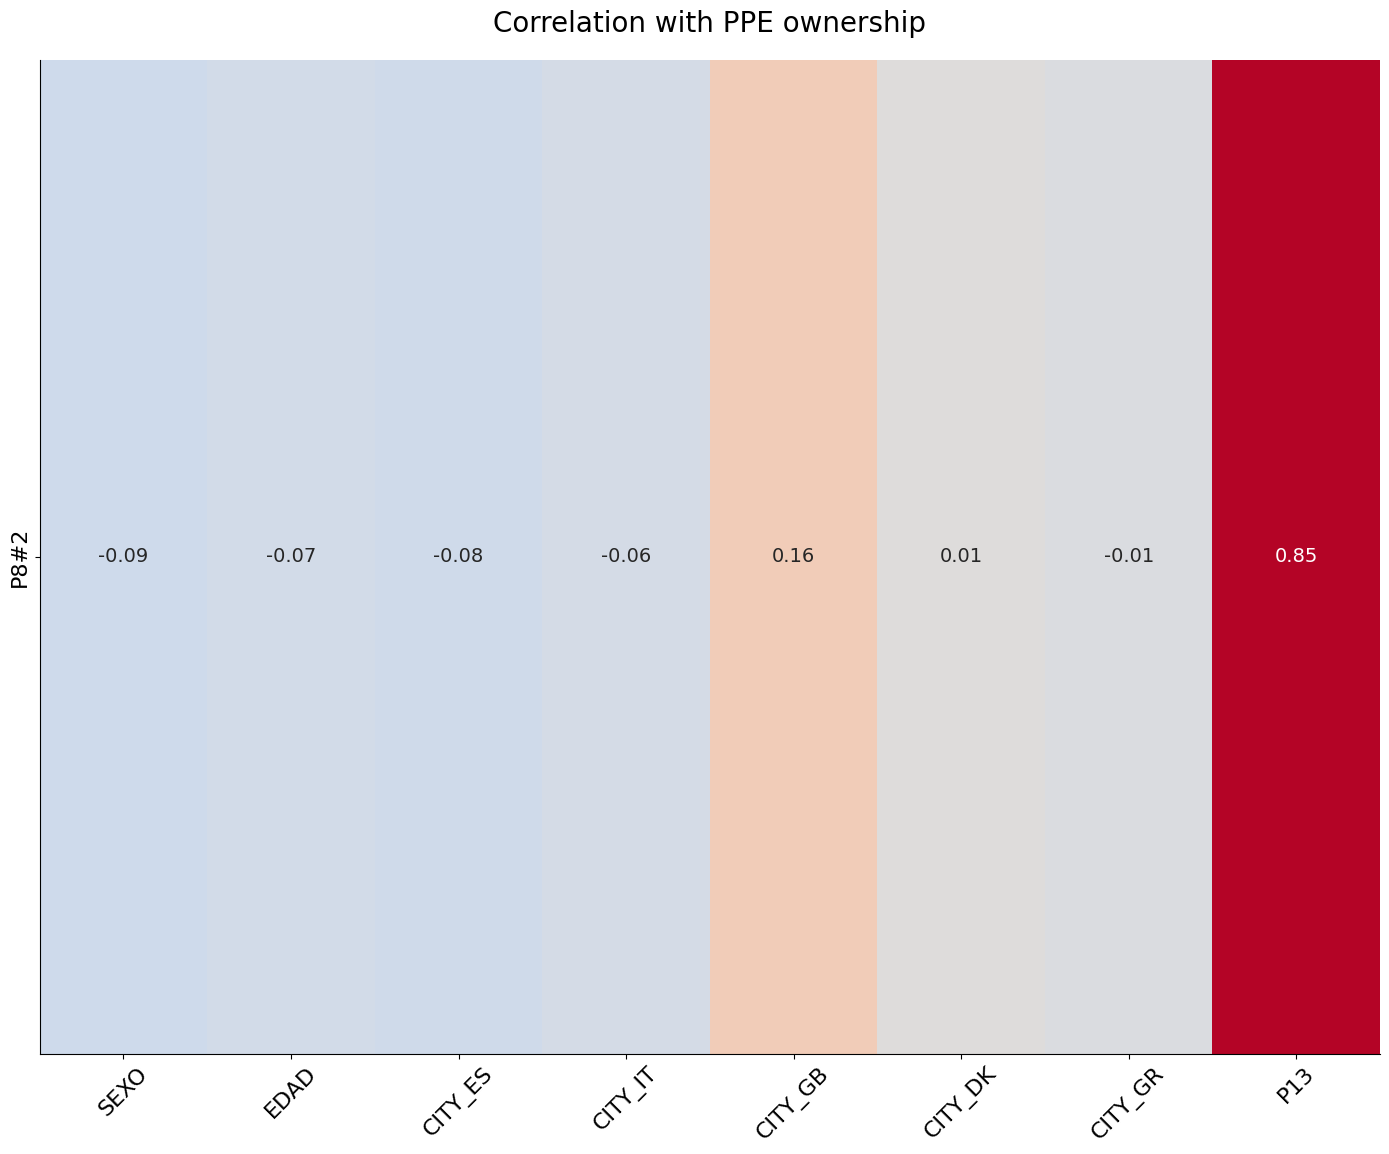

In [16]:
jacket_rellevant_cols = {
    "ownership": 45,
    # "satisfaction": [66, 67, 68, 69],
    "usage": 74,
    # "reasons": [75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86],
    # "reasons_test": 87,
    # "statements": [88,89, 90, 91, 92, 93, 94, 95, 96, 97]
}

jacket_corr, jacket_df = analyze_ppe_usage(
    df=motocycle_df,
    ppe_cols=jacket_rellevant_cols,
    demographics_cols=demographics_col
)


In [17]:
summary = usage_summary(jacket_df, 74, name="Jacket")

jacket_df.iloc[:, 74].value_counts()

Jacket - Mean: 1.79
Own but not always using: 343, Percentage: 62.82%
Own but never using: 2, Percentage: 0.37%


P13
2.0    259
1.0    201
3.0     84
4.0      2
Name: count, dtype: int64

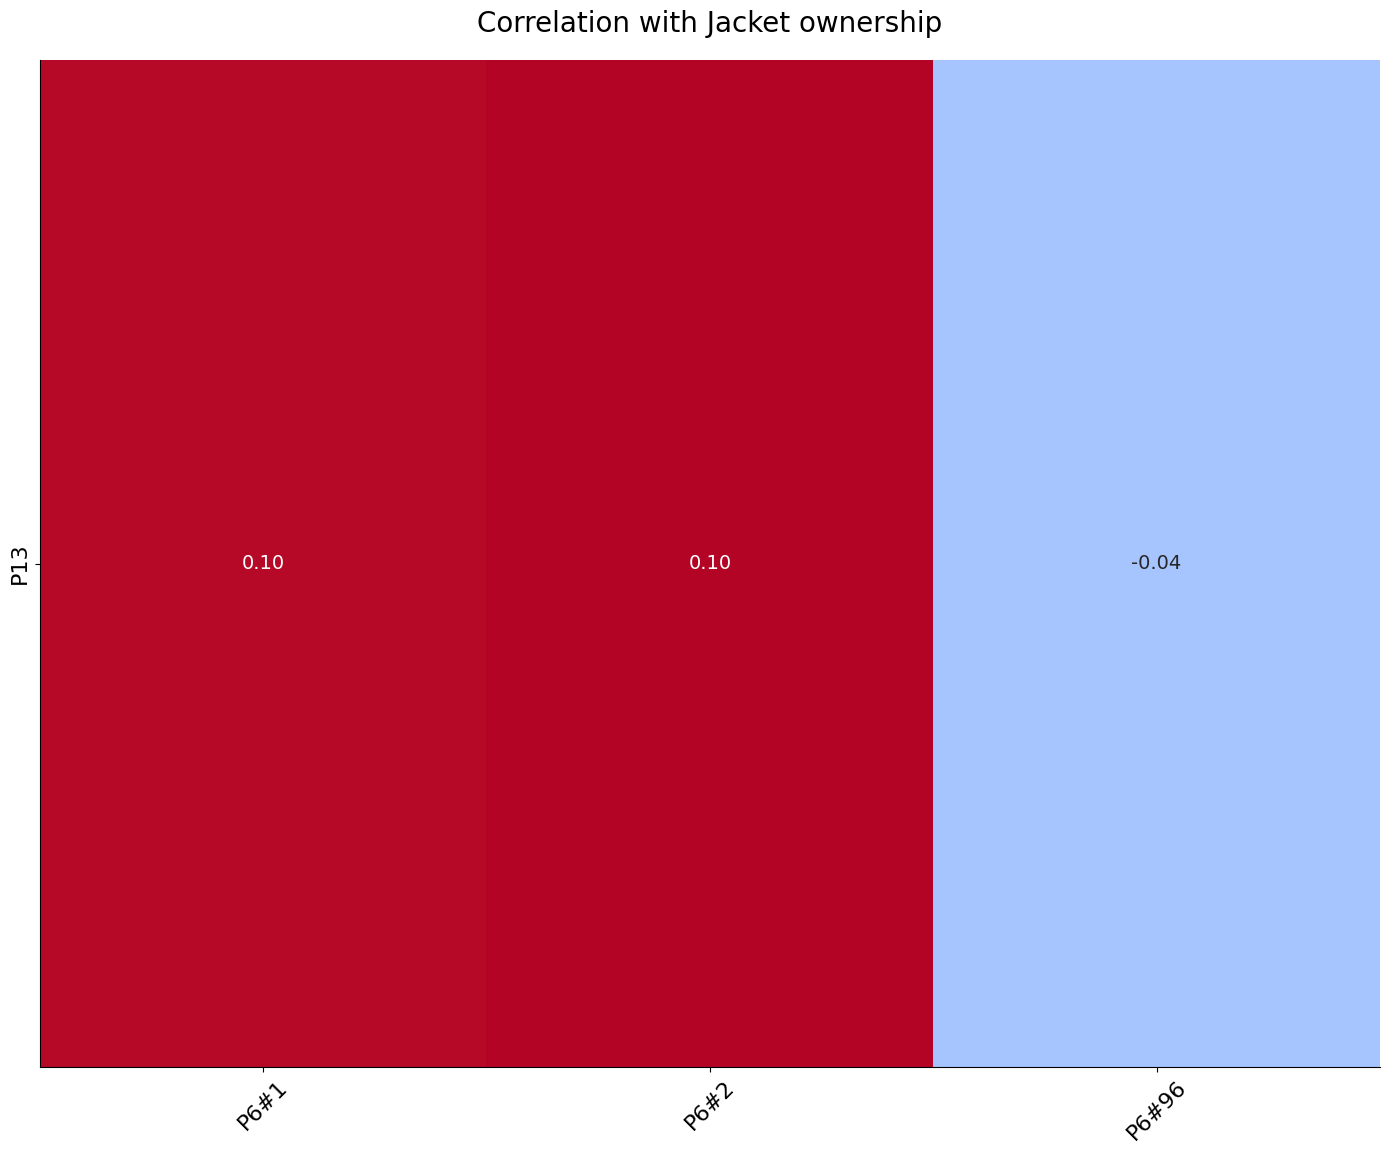

In [18]:
#Type of road
columns = motocycle_df.columns[35:38]

# Example usage
target_col = motocycle_df.columns[74]
jacket_corr =  plot_target_correlations(
    df=motocycle_df,
    target_col=target_col,
    numeric_cols=[target_col] + list(columns),
    label = "Jacket ownership",
)

In [19]:
cols = jacket_df.columns[66:70]
jacket_satisfaction = plot_satisfaction_bar_plotnine(
    df=jacket_df,
    cols=cols,
    variables_df=variables_df,
    title = "Satisfaction with Jacket")
jacket_satisfaction.save(FIGURES_DIR/"jacket_satisfaction.png")

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 14 x 11.64 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\jacket_satisfaction.png


### Leg Protector

Available data for leg protector usage by motocyclists:

- **Ownership** (Column 8)
- **Satisfaction** (Column 12)
- **Frequency of usage** (Column 17)
- **Reasons for not using** (Column 18)
- **Statements** (Column 19)
- **Type** (Column 20)


Leg Protector users: 314 , Leg Protector ownership rate: 0.35 %


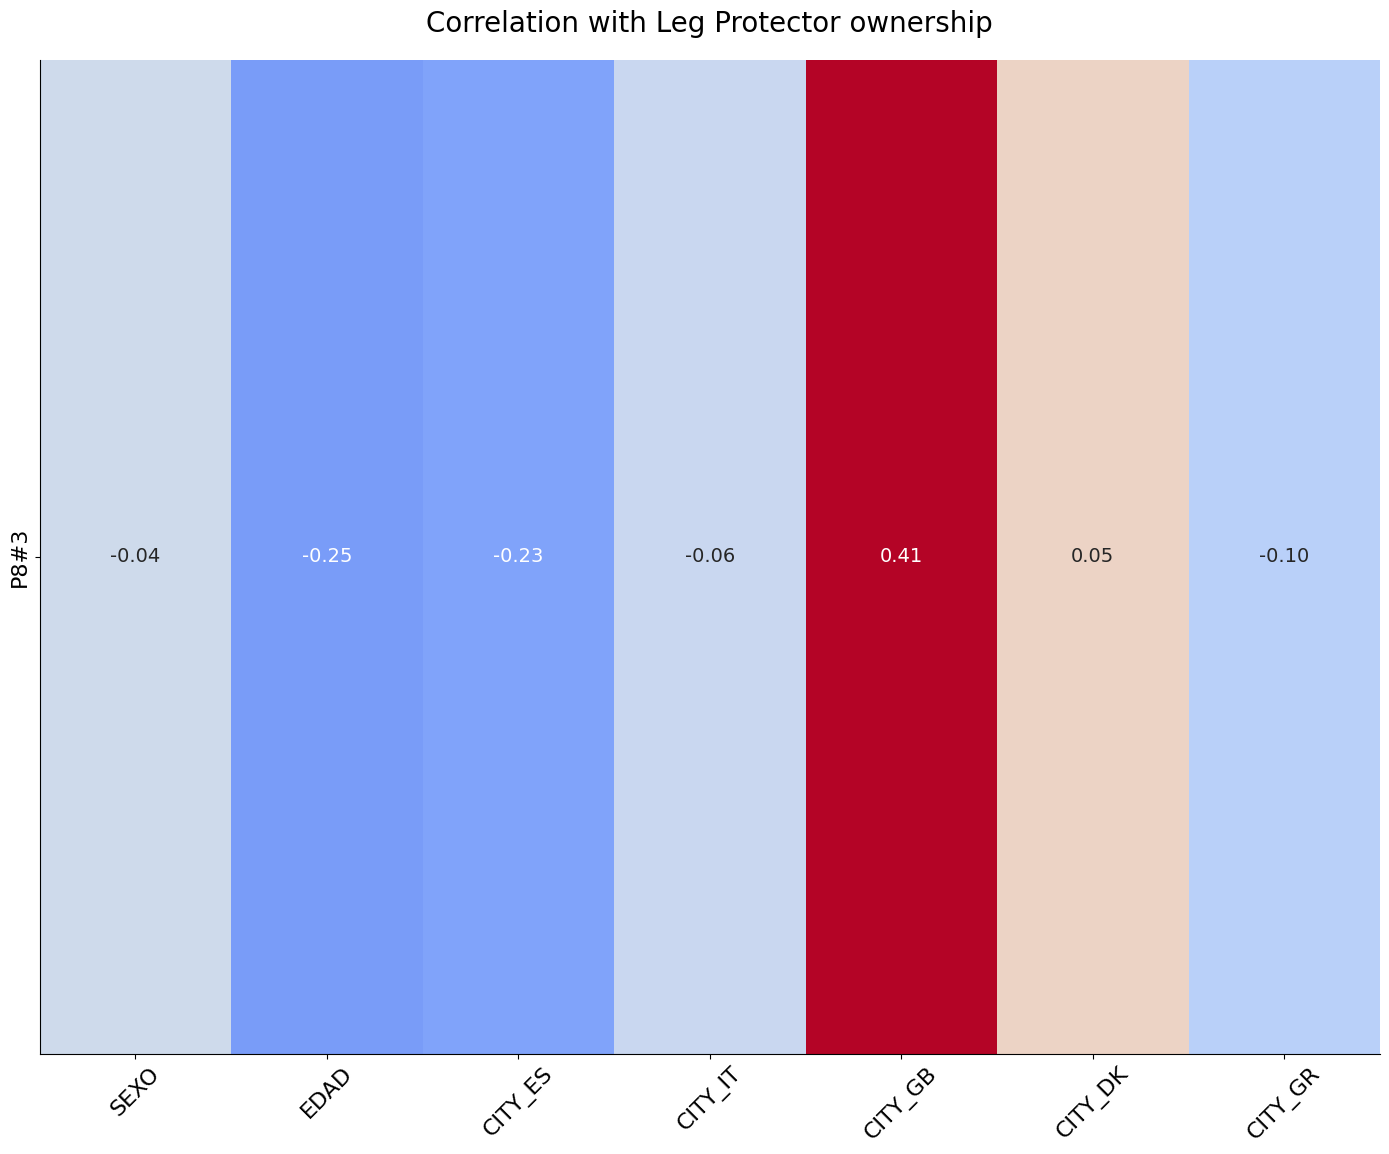

In [20]:
# Leg Protector ownership
leg_protector_df = motocycle_df[motocycle_df.iloc[:, 46] == 1]
print("Leg Protector users:", leg_protector_df.shape[0], ", Leg Protector ownership rate:", round(leg_protector_df.shape[0] / motocycle_df.shape[0], 2),"%")

motocycle_df.iloc[:, 46].value_counts()

# Example usage
target_col = leg_protector_df.columns[46]

leg_protector_corr =  plot_target_correlations(
    df=motocycle_df,
    target_col=target_col,
    numeric_cols=[target_col] + demographics_col,
    label = "Leg Protector ownership",
)




In [21]:
summary = usage_summary(leg_protector_df, 99, name="Leg Protector")
leg_protector_df.iloc[:, 99].value_counts()

Leg Protector - Mean: 1.87
Own but not always using: 177, Percentage: 56.37%
Own but never using: 9, Percentage: 2.87%


P17
1.0    128
2.0    108
3.0     69
4.0      9
Name: count, dtype: int64

In [22]:
cols = leg_protector_df.columns[70:74]

leg_protector_satisfaction = plot_satisfaction_bar_plotnine(
    leg_protector_df,
    variables_df=variables_df,
    cols = cols,
    title="Satisfaction with Leg Protector",
)
leg_protector_satisfaction.save(FIGURES_DIR/"leg_protector_satisfaction.png")



c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 14 x 11.64 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\leg_protector_satisfaction.png


# Save data

In [24]:
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# #Helmet
# helmet_satisfaction.savefig(FIGURES_DIR / "satisfaction_helmet.png")
# helmet_corr.savefig(FIGURES_DIR / "correlation_helmet.png")

# #Jacket
# jacket_satisfaction.savefig(FIGURES_DIR / "satisfaction_jacket.png")
# jacket_corr.savefig(FIGURES_DIR / "correlation_jacket.png")

# #Leg Protector
# leg_protector_satisfaction.savefig(FIGURES_DIR / "satisfaction_leg_protector.png")
# leg_protector_corr.savefig(FIGURES_DIR / "correlation_leg_protector.png")